# Exploratory Data Analysis (EDA)

## 1. Load Libraries

## 2. Load Datasets

## 3. NAV Trend Analysis

## 4. AUM Growth Analysis

## 5. SIP Inflow Analysis

## 6. Category Inflow Heatmap

## 7. Investor Demographics

## 8. Geographic Analysis

## 9. Folio Growth

## 10. Correlation Analysis

## 11. Sector Allocation

## 12. Key Findings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display all columns
pd.set_option("display.max_columns", None)

In [4]:
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [5]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Transactions: (32778, 13)
Holdings: (322, 8)


In [6]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [8]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

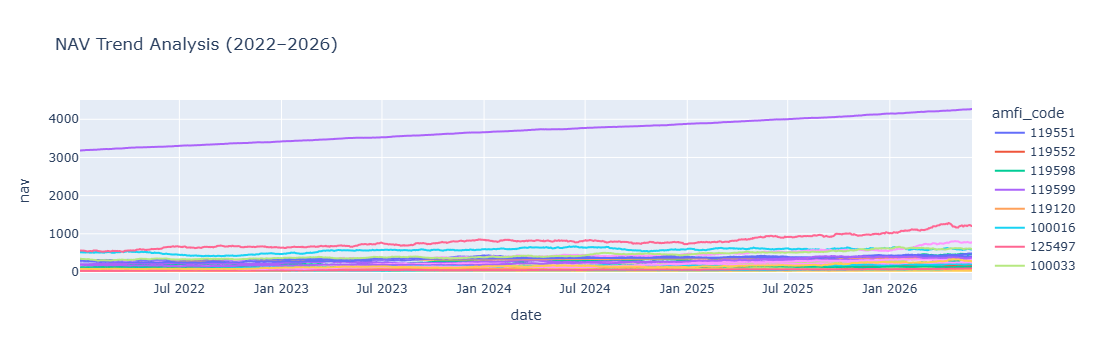

In [9]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022–2026)"
)

fig.show()

## Insight

NAV values generally show an upward trend across most mutual fund schemes, indicating long-term growth despite market fluctuations.

In [10]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [11]:
# Dataset shapes
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category Inflows:", category.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category Inflows: (144, 3)


In [12]:
# Check columns
print(fund_master.columns)
print(nav_history.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [15]:
print(nav_history.columns.tolist())

['amfi_code', 'date', 'nav']


In [16]:
print(nav_history.columns.tolist())

['amfi_code', 'date', 'nav']


In [17]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

# Mutual Fund EDA Analysis

In [18]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")

In [19]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [20]:
nav_merged = pd.merge(
    nav_history,
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav_merged.head())

   amfi_code        date      nav                                scheme_name
0     119551  2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551  2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551  2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551  2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551  2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


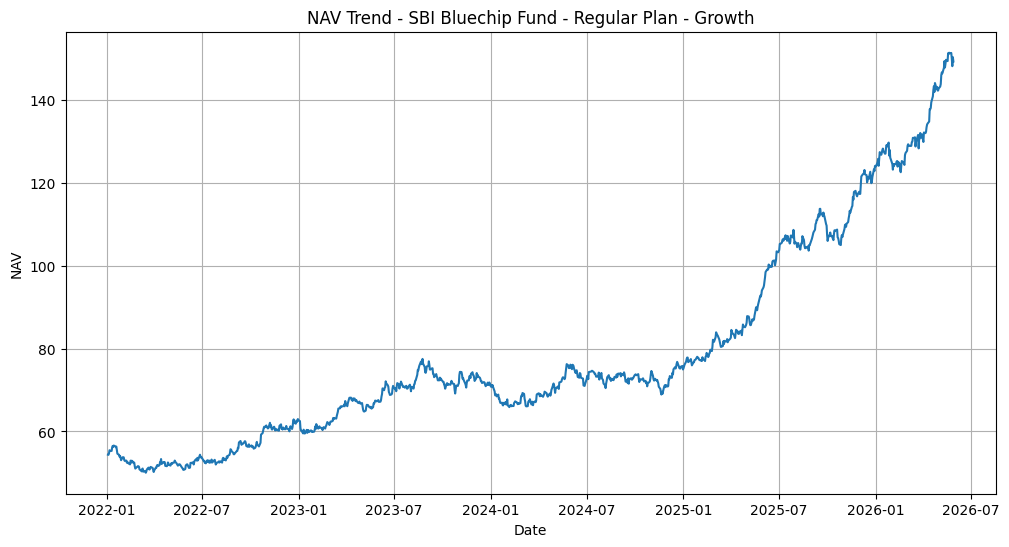

In [62]:
import matplotlib.pyplot as plt

# Convert date
nav_merged['date'] = pd.to_datetime(nav_merged['date'])

# Select first fund
fund = nav_merged['scheme_name'].dropna().iloc[0]

# Filter data
df = nav_merged[nav_merged['scheme_name'] == fund]

# Sort by date
df = df.sort_values('date')

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['nav'])

plt.title(f'NAV Trend - {fund}')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.grid(True)
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 1

The NAV of the selected mutual fund shows a long-term upward trend, indicating wealth creation potential despite short-term market fluctuations.

In [22]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

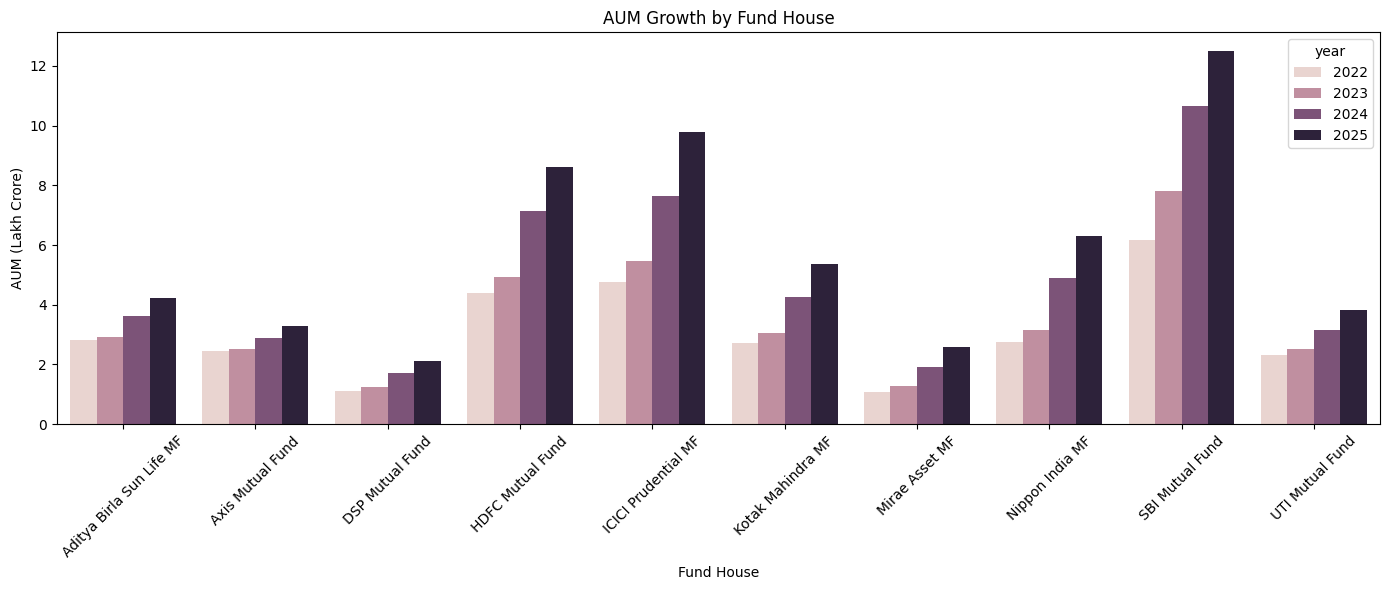

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date
aum['date'] = pd.to_datetime(aum['date'])

# Extract year
aum['year'] = aum['date'].dt.year

# Average yearly AUM
aum_yearly = (
    aum.groupby(['year', 'fund_house'])['aum_lakh_crore']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year'
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 2

Large fund houses consistently maintain higher AUM levels, indicating stronger investor trust and market presence.

In [24]:
sip.columns.tolist()

['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

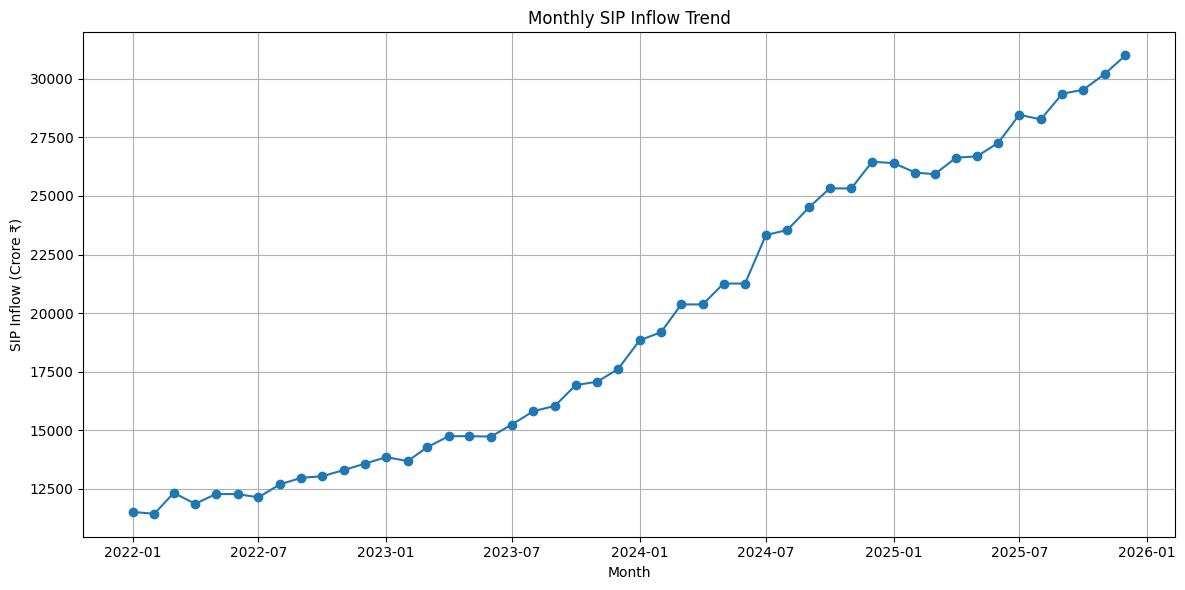

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month column
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title('Monthly SIP Inflow Trend')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore ₹)')
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 3

SIP inflows have shown a strong upward trend over the study period, indicating increasing retail investor participation in mutual funds.

In [27]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

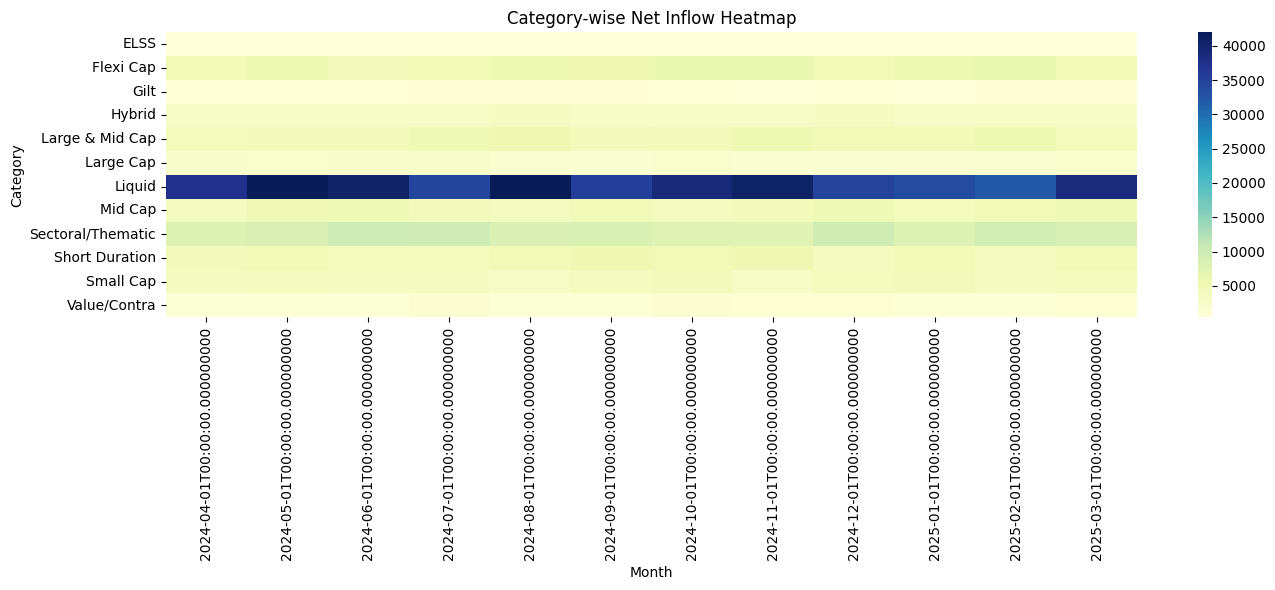

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month column
category['month'] = pd.to_datetime(category['month'])

# Create pivot table
heatmap_data = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')

plt.tight_layout()
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 4

Certain fund categories consistently attract higher inflows, indicating stronger investor preference and market confidence.

In [29]:
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


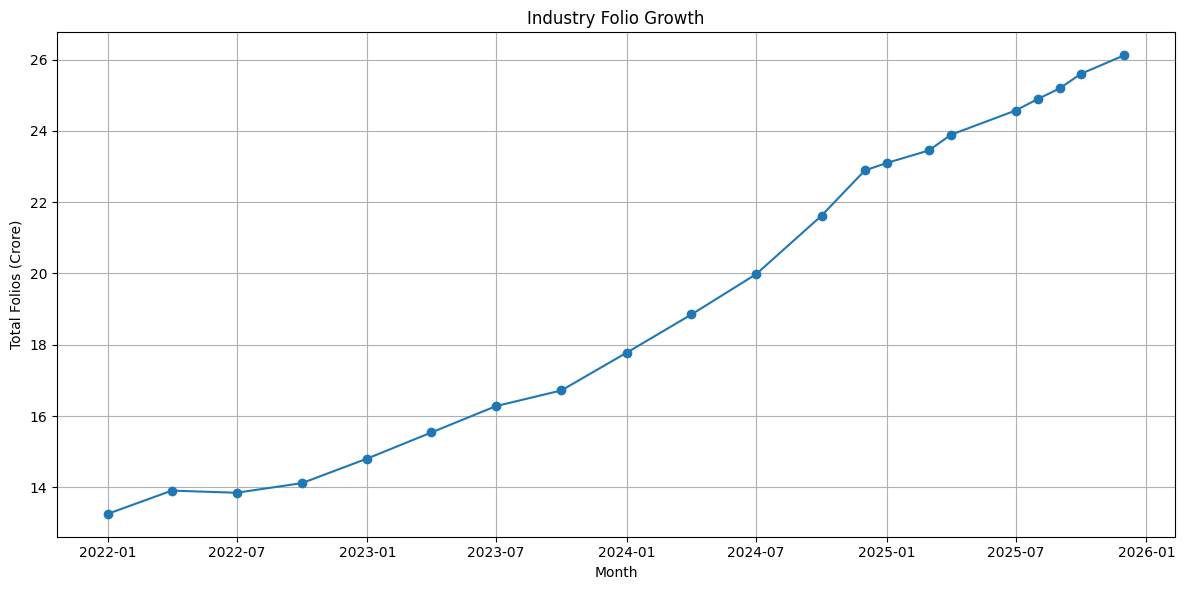

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month column
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title('Industry Folio Growth')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.grid(True)

plt.tight_layout()
plt.show()

# EDA Finding 5

Total folio count has grown steadily during the study period, indicating increasing participation of retail investors in mutual funds.

In [34]:
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


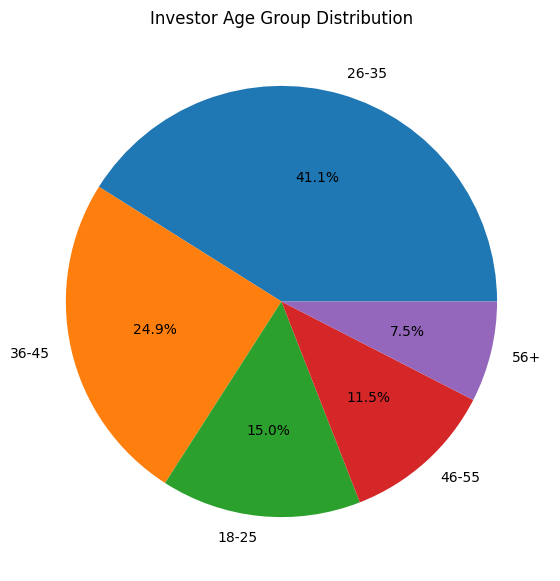

In [58]:
import matplotlib.pyplot as plt

age_counts = transactions['age_group'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 6

The majority of mutual fund investors belong to a few dominant age groups, highlighting the primary target segments for investment products.

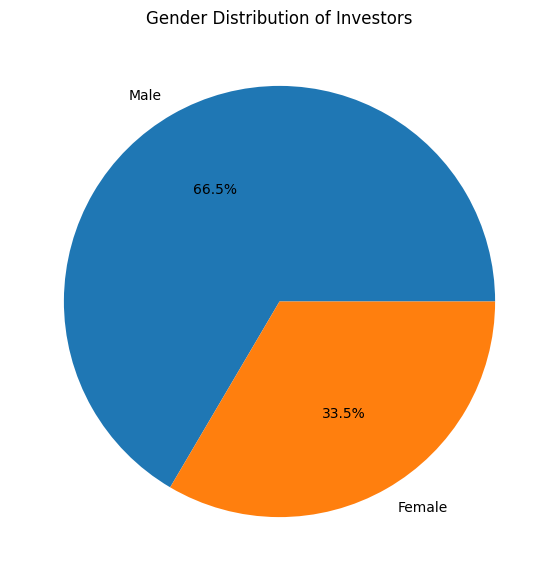

In [57]:
gender_counts = transactions['gender'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Investors')
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 7

Investor participation differs across genders, providing insight into demographic investment behaviour.

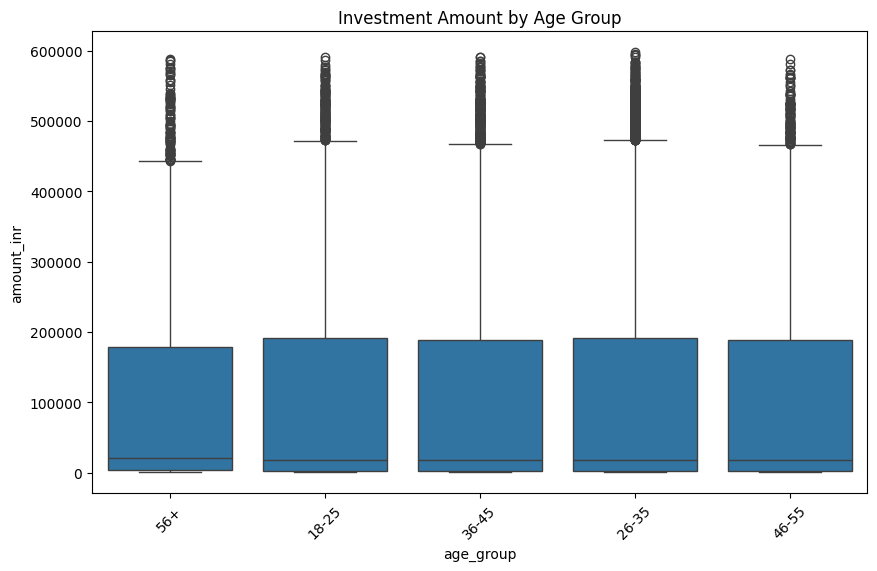

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount by Age Group')
plt.xticks(rotation=45)
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 8

Investment amounts vary across age groups, with some segments displaying higher investment capacity and wider transaction ranges.

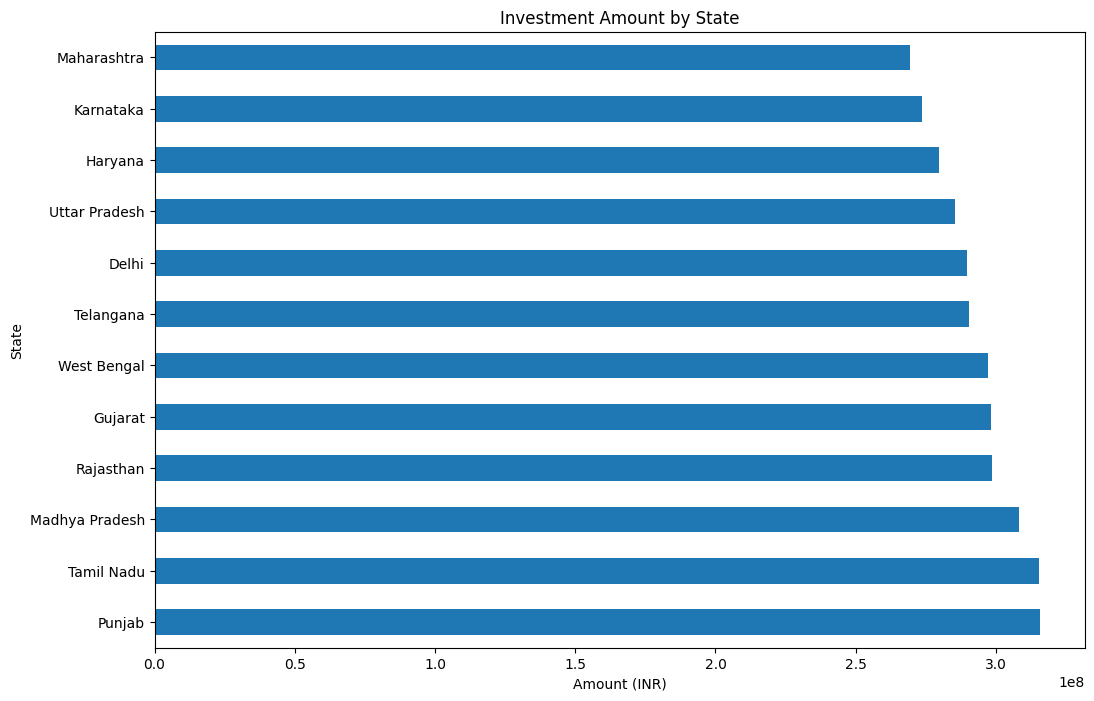

In [55]:
state_data = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_data.plot(kind='barh')

plt.title('Investment Amount by State')
plt.xlabel('Amount (INR)')
plt.ylabel('State')
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

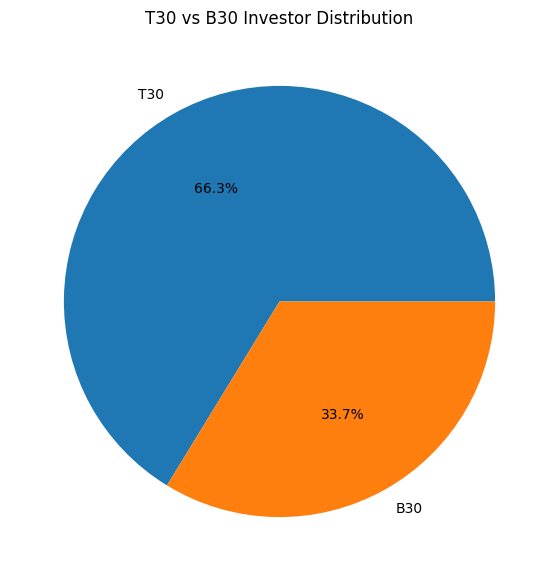

In [54]:
tier_counts = transactions['city_tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 9

Investors are concentrated in major metropolitan markets, though participation from smaller cities continues to grow.

In [40]:
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [41]:
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


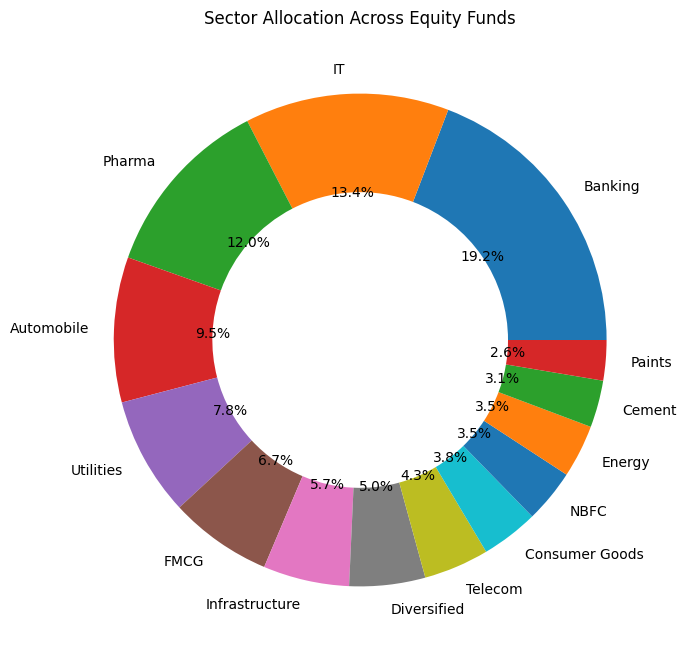

In [53]:
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

sector_weights = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation Across Equity Funds")
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 10

Financials, IT, and other major sectors account for a significant share of mutual fund portfolios, indicating sector concentration within equity schemes.

In [43]:
nav_merged.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [44]:
print(nav_merged.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name']


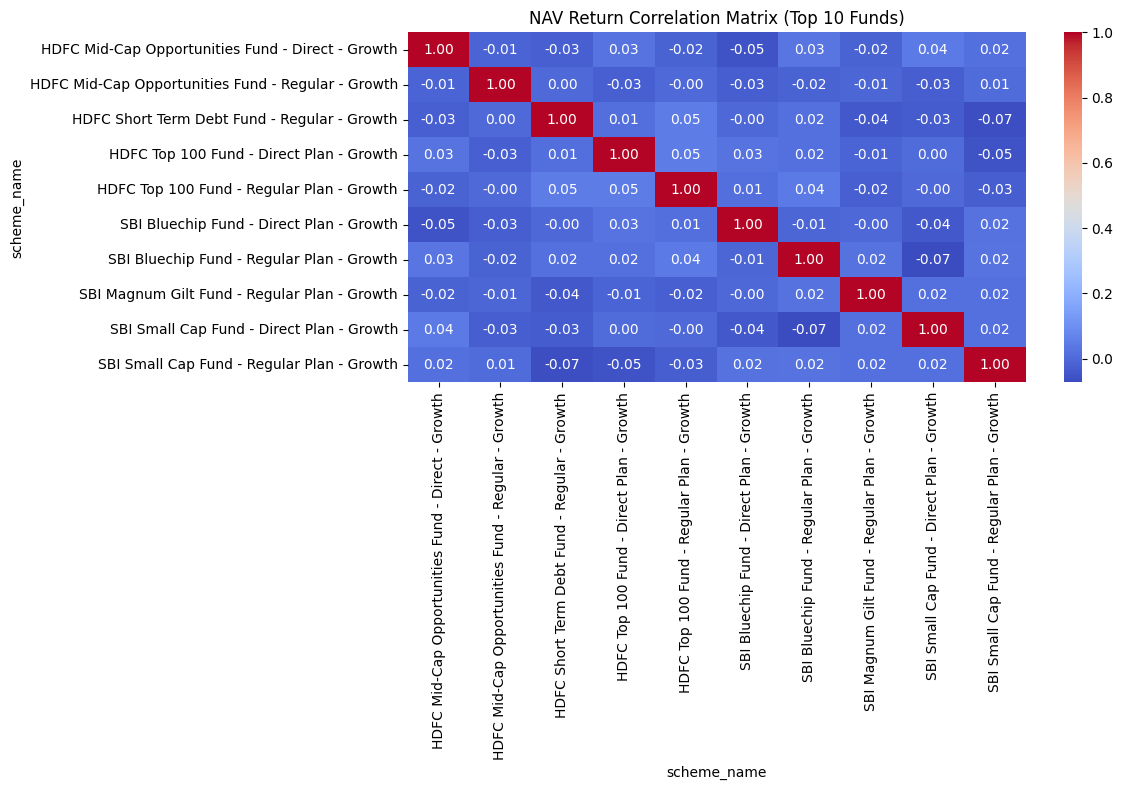

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select 10 funds
top_funds = nav_merged['scheme_name'].dropna().unique()[:10]

df = nav_merged[nav_merged['scheme_name'].isin(top_funds)]

# Pivot table
pivot_df = df.pivot_table(
    index='date',
    columns='scheme_name',
    values='nav'
)

# Daily returns
returns = pivot_df.pct_change()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix (Top 10 Funds)')

plt.tight_layout()
plt.savefig("../reports/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA Finding 11

Several equity funds exhibit strong positive correlations, reflecting their exposure to similar market conditions and benchmark indices.

In [49]:
print(corr_matrix.shape)
corr_matrix.head()

(10, 10)


scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296


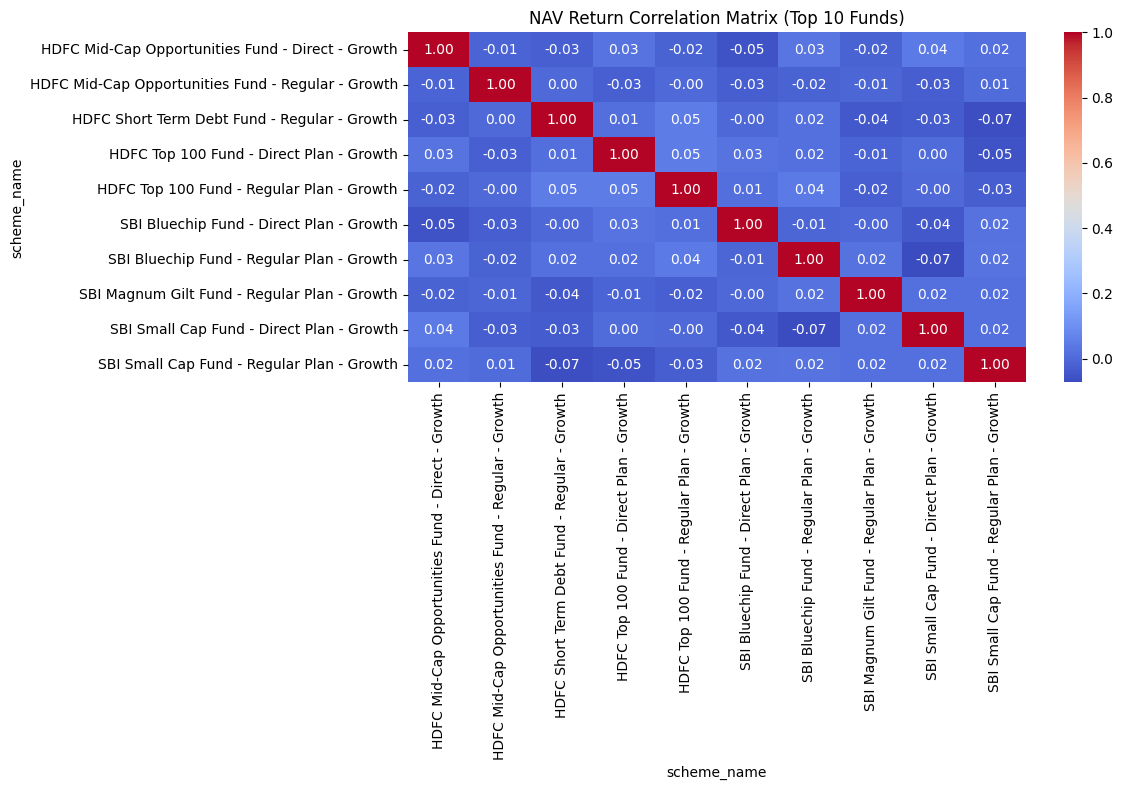

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.close('all')

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.show()